In [2]:
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
from Labeling import *
from purged_cv_by_date import *

# 1. Train Primary Model to Predict up/down movement at events

In the first step we use a Random Forest Model to predict given the Features at an event wether the stock goes up or down, wether to go long or short at that event. 
We ignored events with the same price level at vertical barrier, as the label 0 in this case would indicate doing nothing, which is later done by using a secondary model to predict wether Trade should be made or not. 

## Extract Trading Dates and Prices

In [3]:
with open("./Data/stocks.pkl", "rb") as file: 
    stocks = pkl.load(file)

In [4]:
prices = stocks[["PERMNO", "Date", "DlyClose"]]

In [5]:
prices = prices.set_index(["Date", "PERMNO"], drop=True)
prices = prices.loc[~prices.index.duplicated(keep='first'), :]

In [6]:
prices

,,DlyClose
Date,PERMNO,
2013-01-02,10026,64.3200
2013-01-03,10026,64.6800
2013-01-04,10026,64.7700
2013-01-07,10026,63.4007
2013-01-08,10026,63.4300
...,...,...
2023-12-22,93429,175.5300
2023-12-26,93429,173.6900
2023-12-27,93429,175.6100


## Read in Side-labeled Data

In [7]:
with open("./Data/feature_scores_events.pkl", "rb") as file:
    data = pkl.load(file)

In [8]:
data.describe()

,Date,PERMNO,ma_5,ema_5,slope_ma_5,ma_10,ema_10,slope_ma_10,ma_20,ema_20,...,pv_corr,pv_divergence,label,DlyClose,timestamp,End Time,Return,trade_days,Return_dly,Side
count,688224,688224.000000,688224.000000,688224.000000,688224.000000,688224.000000,688224.000000,688224.000000,688224.000000,688224.000000,...,688224.000000,688224.000000,688224.000000,688224.000000,688224,688224,688224.000000,688224.000000,688224.000000,688224.000000
mean,2018-08-07 20:21:03.063188480,66195.741782,0.006251,0.006304,0.007949,0.006261,0.006244,-0.002353,0.006197,0.006096,...,0.003224,-0.003224,0.002897,57.610769,2018-08-07 20:21:03.063188480,2018-08-12 07:04:26.522527744,0.002202,4.059103,0.000593,0.012258
min,2013-04-04 00:00:00,10026.000000,-1.025310,-1.025152,-7.088935,-1.024847,-1.024539,-6.734629,-1.024029,-1.022825,...,-2.491097,-3.332061,-0.950092,0.040600,2013-04-04 00:00:00,2013-04-05 00:00:00,-0.903307,2.000000,-0.400972,-1.000000
25%,2015-11-24 00:00:00,38093.000000,-0.619627,-0.619671,-0.387763,-0.619814,-0.619955,-0.377465,-0.620055,-0.620458,...,-0.754614,-0.732845,-0.022691,13.020000,2015-11-24 00:00:00,2015-12-02 00:00:00,-0.025090,2.000000,-0.007515,-1.000000
50%,2018-08-14 00:00:00,81621.000000,-0.317590,-0.317421,-0.013043,-0.317315,-0.317345,-0.027073,-0.316977,-0.317004,...,-0.026778,0.026778,0.001392,31.920000,2018-08-14 00:00:00,2018-08-17 00:00:00,0.007318,3.000000,0.001453,0.000000
75%,2021-05-11 00:00:00,89708.000000,0.260188,0.260132,0.387345,0.260470,0.260658,0.355186,0.261000,0.260913,...,0.732845,0.754614,0.024631,66.670000,2021-05-11 00:00:00,2021-05-13 00:00:00,0.025641,5.000000,0.007610,1.000000
max,2023-12-01 00:00:00,93429.000000,6.124177,6.118742,6.570649,6.104151,6.095153,6.785469,6.084156,6.061786,...,3.332061,2.491097,208.852217,3696.060000,2023-12-01 00:00:00,2023-12-21 00:00:00,103.187192,16.000000,20.637438,1.000000
std,NaN,30127.982968,1.002969,1.003000,1.089839,1.002969,1.002965,1.028496,1.002867,1.002767,...,1.012377,1.012377,0.319197,110.095093,NaN,NaN,0.169074,2.569951,0.049418,0.804423


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688224 entries, 0 to 688223
Data columns (total 58 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                688224 non-null  datetime64[ns]
 1   PERMNO              688224 non-null  int64         
 2   ma_5                688224 non-null  float64       
 3   ema_5               688224 non-null  float64       
 4   slope_ma_5          688224 non-null  float64       
 5   ma_10               688224 non-null  float64       
 6   ema_10              688224 non-null  float64       
 7   slope_ma_10         688224 non-null  float64       
 8   ma_20               688224 non-null  float64       
 9   ema_20              688224 non-null  float64       
 10  slope_ma_20         688224 non-null  float64       
 11  ma_60               688224 non-null  float64       
 12  ema_60              688224 non-null  float64       
 13  slope_ma_60         688224 no

In [10]:
data.columns

Index(['Date', 'PERMNO', 'ma_5', 'ema_5', 'slope_ma_5', 'ma_10', 'ema_10',
       'slope_ma_10', 'ma_20', 'ema_20', 'slope_ma_20', 'ma_60', 'ema_60',
       'slope_ma_60', 'ret_1', 'ret_5', 'ret_10', 'ret_20', 'macd_dif',
       'macd_dea', 'macd', 'macd_cross', 'bb_mid', 'bb_upper', 'bb_lower',
       'bb_pctB', 'rsi', 'rsv_10', 'rsv_20', 'aroon_up_10', 'aroon_down_10',
       'aroon_up_20', 'aroon_down_20', 'range_hl_over_c', 'atr', 'gap_oc_prev',
       'gap_cc_prev', 'shadow_upper_ratio', 'shadow_lower_ratio', 'ret_c2c',
       'ret_co', 'ret_oc', 'vol', 'adv', 'dvol', 'vol_z', 'turnover_proxy',
       'vwap_proxy', 'pv_corr', 'pv_divergence', 'label', 'DlyClose',
       'timestamp', 'End Time', 'Return', 'trade_days', 'Return_dly', 'Side'],
      dtype='object')

In [11]:
data["Side"].value_counts()

Side
 0.0    242774
 1.0    226943
-1.0    218507
Name: count, dtype: int64

## 1.1 Hyperparameter Tuning for Random Forest using Smaller Time Period

In [18]:
data_cv = data[(data["Date"]>= "2016-01-01") & (data["Date"]<= "2017-01-01")]

In [19]:
#drop forward looking columns from Features
X_cv = data_cv.drop(columns=["PERMNO", "label", "End Time","DlyClose", "timestamp", "Side"])
y_cv = data_cv["Side"]

In [20]:
#iterable Hyperparameter Combinations
cv_params = {'max_depth': [3, 5, 7, None], 
             'min_samples_leaf': [1, 3, 5],
             'n_estimators': [100, 200, 300]
             }  

params_comb = param_grid_dicts(cv_params)

In [21]:
#Test purged CV by Date
n_splits = 5
folds = purged_kfold_indices_by_date(X_cv, n_splits=n_splits, purge_days= 60)
test_purged_cv_by_date(X_cv, folds, purge_days=60 )

Fold 0: violations = 0
Fold 1: violations = 0
Fold 2: violations = 0
Fold 3: violations = 0
Fold 4: violations = 0


In [26]:
print(folds)

[(array([111333, 111334, 111335, ..., 493416, 493417, 493418],
      shape=(382086,)), array([     0,      1,      2, ..., 100798, 100799, 100800],
      shape=(100801,))), (array([     0,      1,      2, ..., 493416, 493417, 493418],
      shape=(369128,)), array([100801, 100802, 100803, ..., 201544, 201545, 201546],
      shape=(100746,))), (array([     0,      1,      2, ..., 493416, 493417, 493418],
      shape=(377826,)), array([201547, 201548, 201549, ..., 297951, 297952, 297953],
      shape=(96407,))), (array([     0,      1,      2, ..., 493416, 493417, 493418],
      shape=(372357,)), array([297954, 297955, 297956, ..., 397589, 397590, 397591],
      shape=(99638,))), (array([     0,      1,      2, ..., 386817, 386818, 386819],
      shape=(386820,)), array([397592, 397593, 397594, ..., 493416, 493417, 493418],
      shape=(95827,)))]


In [59]:
from sklearn.ensemble import RandomForestClassifier
from purged_cv import purged_kfold_indices
from sklearn.metrics import f1_score

#Use Date based purged CV using 60 Day purge size, given that max horizon used in feature computation is 60 day window.
n_splits = 5
folds = purged_kfold_indices_by_date(X_cv, n_splits=n_splits, purge_days= 60)

#now drop date
X_cv = X_cv.drop(columns=["Date"])

results = []

for params in params_comb:
    print(params)

    f1_scores = []
    avg_pred_prob = [] 

    for fold, (train_idx, test_idx) in enumerate(folds, 1):
        
        # Extract training and test data for this fold.
        X_t, y_t = X_cv.iloc[train_idx , : ], y_cv.iloc[train_idx]
        X_val, y_val = X_cv.iloc[test_idx, : ], y_cv.iloc[test_idx]

        # Fit the model using XGBRegressor.
        model = RandomForestClassifier(n_estimators = params["n_estimators"], 
                                       min_samples_leaf=params["min_samples_leaf"],
                                       max_depth=params["max_depth"],
                                       class_weight='balanced',
                                       n_jobs=-1,
                                       random_state=42)
        
        model.fit(X_t, y_t)

        #compute 
        y_pred = model.predict(X_val)

        f1 = f1_score(y_pred=y_pred, y_true=y_val)
        prob = np.max(model.predict_proba(X_val) , axis = 1)

        f1_scores.append(f1)
        avg_pred_prob.append(np.mean(prob))

    mean_F1 = np.mean(f1_scores)
    mean_prob = np.mean(avg_pred_prob)
    
    result_entry = {
        **params,
        "avg F1" : mean_F1,
        "avg confidence" : mean_prob,
    }

    results.append(result_entry)
    print(f"mean F1 Score: {mean_F1},  mean Confidence: {mean_prob}")


{'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 100}
mean F1 Score: 0.5630831734221464,  mean Confidence: 0.5167024807750296
{'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 200}
mean F1 Score: 0.5649088658006891,  mean Confidence: 0.5161752589988345
{'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 300}
mean F1 Score: 0.5651254154380124,  mean Confidence: 0.5159783175062385
{'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 100}
mean F1 Score: 0.562706667729014,  mean Confidence: 0.5166991437819839
{'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 200}
mean F1 Score: 0.5649620766512615,  mean Confidence: 0.5161740110132615
{'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 300}
mean F1 Score: 0.5648868737115234,  mean Confidence: 0.5159764620954788
{'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 100}
mean F1 Score: 0.583119800388479,  mean Confidence: 0.525547087198371
{'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 200}
mean F1 Sco

In [75]:
#sort according to best average weighted F1 Score
df_results = pd.DataFrame(results).sort_values(by="weighted F1", ascending=False)
df_results

,max_depth,min_samples_leaf,n_estimators,weighted F1,avg confidence
23,NaN,5,300,0.641002,0.582041
20,NaN,3,300,0.639535,0.585621
22,NaN,5,200,0.637688,0.583016
19,NaN,3,200,0.637526,0.586883
21,NaN,5,100,0.632830,0.586712
18,NaN,3,100,0.631672,0.591138
14,7.0,3,300,0.605578,0.533729
13,7.0,3,200,0.604344,0.534119
17,7.0,5,300,0.602845,0.533744
12,7.0,3,100,0.601400,0.534632


Based on the Hyperparameter Tuning, the Hyperparameter among the best performing ones, that regularize the tree the most to avoid overfitting. 
As criterion we choose the weighted F1 Score and the average probability of the class label with the highest probability, which is interpreted as confidence.
Thus The Parameter configuration: max_depth: 7, min_samples_leaf: 5, and n_estimators = 100 and max_depth: None, min_samples_leaf:5, n_estimators 100 are considered for the final model. 

## 1.2 Train Primary Model with purged CV - Random Forest

In [12]:
Label_cols = ['PERMNO','label', 'DlyClose', 'timestamp', 'End Time', 'Return', 'trade_days', 'Return_dly', 'Side']

In [13]:
data = data.sort_values("Date").reset_index(drop = True)

X_TRAIN = data.loc[data['Date'] < '2021-01-01'].copy()
X_TEST  = data.loc[data['Date'] >= '2021-04-01'].copy() #Introduce Purging into Training and Test Set - no leakage

In [14]:
X_tr = X_TRAIN.drop(columns = Label_cols)
Y_tr = X_TRAIN["Side"]

In [15]:
from sklearn.metrics import classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Fit the Primary model on the Training Data only to create out-of-sample prediction using predicition and probabilities on test set using purged CV
# for the Side Label that is later used in the meta model.
n_samples = X_tr.shape[0]
n_splits = 5

folds = purged_kfold_indices_by_date(
    df=X_tr,
    n_splits=n_splits,
    purge_days=60
)

#Now drop Date
X_tr = X_tr.drop(columns = ["Date"])  
y_tr = Y_tr


# Arrays for out-of-sample prediction and Probability for each Label
oof_proba = np.zeros((n_samples, len(np.unique(y_tr)))) # class probabilities
oof_pred  = np.zeros(n_samples)  # hard labels

for fold, (train_idx, val_idx) in enumerate(folds, 1):
    
    print(f"Fold {fold}")

    X_t, y_t = X_tr.iloc[train_idx , : ], y_tr.iloc[train_idx]
    X_val, y_val = X_tr.iloc[val_idx, : ], y_tr.iloc[val_idx]

    primary = RandomForestClassifier(
        n_estimators   = 100,
        min_samples_leaf = 5,
        max_depth      = None,
        class_weight   = 'balanced',
        n_jobs         = -1,
        random_state   = 42,
    )

    primary.fit(X_t, y_t)

    # Out-of-sample predictions for this fold
    proba_val = primary.predict_proba(X_val)
    pred_val = primary.predict(X_val)

    oof_proba[val_idx, :] = proba_val
    oof_pred[val_idx]     = pred_val

    weighted_F1 = f1_score(y_true=y_val, y_pred=pred_val, average="weighted")
    print(f"OOF weighted F1: {weighted_F1:.4f}")


avg_confidence = np.mean(np.max(oof_proba, axis=1))
print(f"OOF average confidence: {avg_confidence:.4f}")

print(classification_report(y_tr, oof_pred))


Fold 1
OOF weighted F1: 0.5516
Fold 2
OOF weighted F1: 0.5091
Fold 3
OOF weighted F1: 0.5710
Fold 4
OOF weighted F1: 0.5218
Fold 5
OOF weighted F1: 0.4572
OOF average confidence: 0.5244
              precision    recall  f1-score   support

        -1.0       0.42      0.33      0.37    147296
         0.0       0.65      0.78      0.71    190627
         1.0       0.44      0.42      0.43    155624

    accuracy                           0.53    493547
   macro avg       0.51      0.51      0.51    493547
weighted avg       0.52      0.53      0.52    493547



In [16]:
X_TRAIN.loc[:,"pred_Side"] = oof_pred
X_TRAIN.loc[:,"pred_Side_proba"] = np.max(oof_proba, axis=1)

In [17]:
#Check Label Assignment
equal = (X_TRAIN["Side"] == X_TRAIN["pred_Side"]).sum()
accuracy = equal / len(X_TRAIN["Side"])
accuracy

np.float64(0.5339430692517633)

## 1.3 ROC Curve

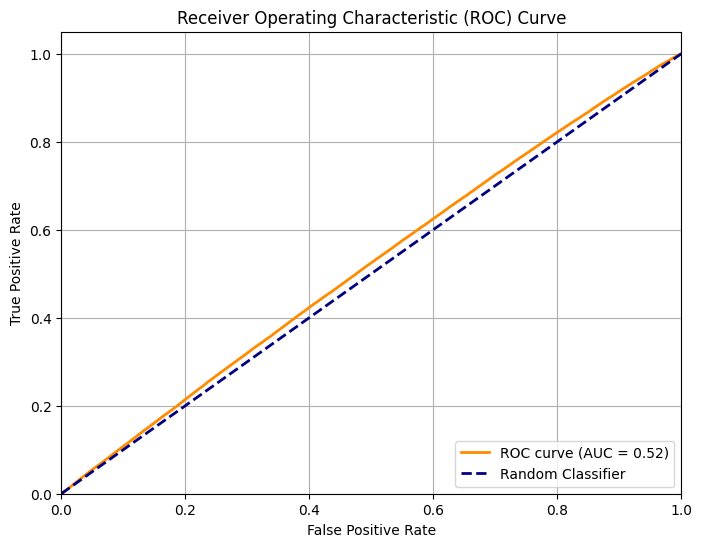

In [88]:
from sklearn.metrics import roc_curve, auc

#Get predicted probabilities for the positive class (class 1)
y_pred_proba = oof_proba[:, 1]

# 5. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(X_TRAIN["Side"], y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 1.4 Fit Primary Model on complete Training Dataset

In [18]:
X_TRAIN.columns

Index(['Date', 'PERMNO', 'ma_5', 'ema_5', 'slope_ma_5', 'ma_10', 'ema_10',
       'slope_ma_10', 'ma_20', 'ema_20', 'slope_ma_20', 'ma_60', 'ema_60',
       'slope_ma_60', 'ret_1', 'ret_5', 'ret_10', 'ret_20', 'macd_dif',
       'macd_dea', 'macd', 'macd_cross', 'bb_mid', 'bb_upper', 'bb_lower',
       'bb_pctB', 'rsi', 'rsv_10', 'rsv_20', 'aroon_up_10', 'aroon_down_10',
       'aroon_up_20', 'aroon_down_20', 'range_hl_over_c', 'atr', 'gap_oc_prev',
       'gap_cc_prev', 'shadow_upper_ratio', 'shadow_lower_ratio', 'ret_c2c',
       'ret_co', 'ret_oc', 'vol', 'adv', 'dvol', 'vol_z', 'turnover_proxy',
       'vwap_proxy', 'pv_corr', 'pv_divergence', 'label', 'DlyClose',
       'timestamp', 'End Time', 'Return', 'trade_days', 'Return_dly', 'Side',
       'pred_Side', 'pred_Side_proba'],
      dtype='object')

In [19]:
Drop = Label_cols + ["Date", "pred_Side" ,"pred_Side_proba"]

X_train_full_primary = X_TRAIN.drop(columns=Drop)
Y_train_full_primary = X_TRAIN["Side"].values

# Fit Primary Model on complete Training Data
primary_full = RandomForestClassifier(
        n_estimators   = 100,
        min_samples_leaf = 5,
        max_depth      = None,
        class_weight   = 'balanced',
        n_jobs         = -1,
        random_state   = 42,
    )

primary_full.fit(X_train_full_primary, Y_train_full_primary) 


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 1.5 Feature Importance

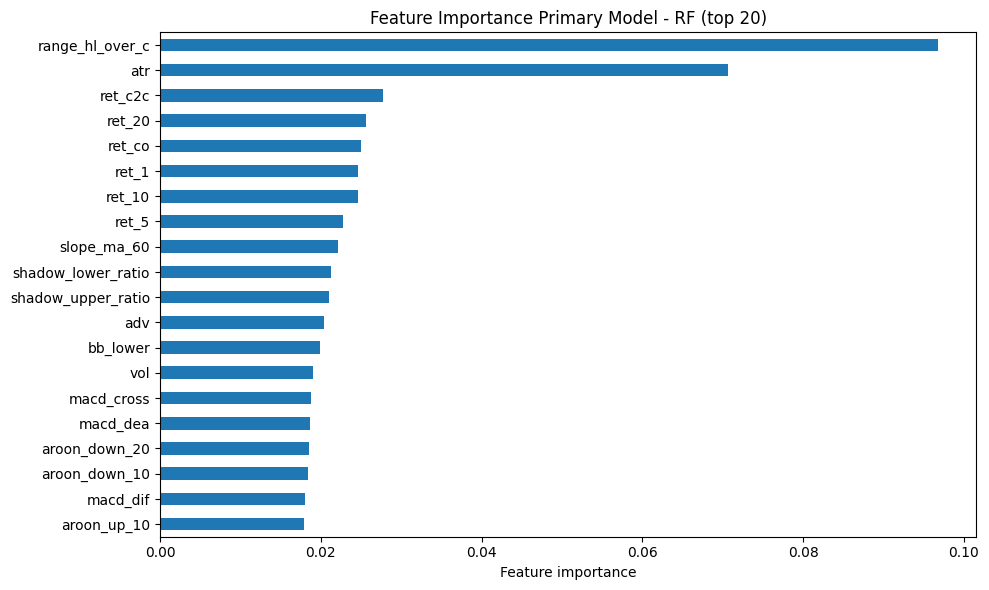

In [23]:
importances = primary.feature_importances_
feat_imp = pd.Series(importances, index=X_train_full_primary.columns).sort_values(ascending=False)
feat_imp_20 = feat_imp.head(20)

plt.figure(figsize=(10, 6))
feat_imp_20[::-1].plot(kind="barh")  # reverse to get largest at top
plt.xlabel("Feature importance")
plt.title(f"Feature Importance Primary Model - RF (top {20})")
plt.tight_layout()
plt.show()

# 2. Train Secondary Model on out-of-sample Side predictions - Random Forest

In [24]:
permno_list = X_TRAIN["PERMNO"].unique()

In [26]:
data_indexed = X_TRAIN.set_index(["Date", "PERMNO"], drop=False)
data_indexed = data_indexed.sort_index(level=0)

In [27]:
data_indexed.columns

Index(['Date', 'PERMNO', 'ma_5', 'ema_5', 'slope_ma_5', 'ma_10', 'ema_10',
       'slope_ma_10', 'ma_20', 'ema_20', 'slope_ma_20', 'ma_60', 'ema_60',
       'slope_ma_60', 'ret_1', 'ret_5', 'ret_10', 'ret_20', 'macd_dif',
       'macd_dea', 'macd', 'macd_cross', 'bb_mid', 'bb_upper', 'bb_lower',
       'bb_pctB', 'rsi', 'rsv_10', 'rsv_20', 'aroon_up_10', 'aroon_down_10',
       'aroon_up_20', 'aroon_down_20', 'range_hl_over_c', 'atr', 'gap_oc_prev',
       'gap_cc_prev', 'shadow_upper_ratio', 'shadow_lower_ratio', 'ret_c2c',
       'ret_co', 'ret_oc', 'vol', 'adv', 'dvol', 'vol_z', 'turnover_proxy',
       'vwap_proxy', 'pv_corr', 'pv_divergence', 'label', 'DlyClose',
       'timestamp', 'End Time', 'Return', 'trade_days', 'Return_dly', 'Side',
       'pred_Side', 'pred_Side_proba'],
      dtype='object')

In [28]:
from Labeling import *
# Based on the Out of Sample Prediction for the Training Data obtained using pruged CV,
# label the event [1,0] if profitable or not.
data_meta_dict = {}

for id in permno_list:
    
    data_sub = data_indexed.xs(id, level="PERMNO").sort_index()
    prices_sub = prices.xs(id, level="PERMNO").sort_index()

    labels = meta_labeling(data_sub, prices_sub["DlyClose"])
    
    labeled_events = pd.merge(data_sub, labels, left_index=True, right_index=True)
    data_meta_dict[id] = labeled_events

In [29]:
X_TRAIN = pd.concat(data_meta_dict, ignore_index=True)

In [30]:
X_TRAIN.columns

Index(['Date', 'PERMNO', 'ma_5', 'ema_5', 'slope_ma_5', 'ma_10', 'ema_10',
       'slope_ma_10', 'ma_20', 'ema_20', 'slope_ma_20', 'ma_60', 'ema_60',
       'slope_ma_60', 'ret_1', 'ret_5', 'ret_10', 'ret_20', 'macd_dif',
       'macd_dea', 'macd', 'macd_cross', 'bb_mid', 'bb_upper', 'bb_lower',
       'bb_pctB', 'rsi', 'rsv_10', 'rsv_20', 'aroon_up_10', 'aroon_down_10',
       'aroon_up_20', 'aroon_down_20', 'range_hl_over_c', 'atr', 'gap_oc_prev',
       'gap_cc_prev', 'shadow_upper_ratio', 'shadow_lower_ratio', 'ret_c2c',
       'ret_co', 'ret_oc', 'vol', 'adv', 'dvol', 'vol_z', 'turnover_proxy',
       'vwap_proxy', 'pv_corr', 'pv_divergence', 'label', 'DlyClose',
       'timestamp', 'End Time', 'Return', 'trade_days', 'Return_dly', 'Side',
       'pred_Side', 'pred_Side_proba', 'Return of Label', 'Label'],
      dtype='object')

In [31]:
X_TRAIN["Label"].value_counts()

Label
0.0    356826
1.0    136721
Name: count, dtype: int64

In [34]:
#include predicted Side and Probabilities in Meta Model
Drop = Label_cols + ["Date", "Return of Label", "Label"]
X_meta = X_TRAIN.drop(columns=Drop)

Y_meta = X_TRAIN["Label"].values

In [35]:
#Fit the Meta Model on the Training Set.
secondary  = RandomForestClassifier(
    n_estimators   = 100,
    min_samples_leaf = 5,
    max_depth      = None,
    class_weight   = 'balanced',
    n_jobs         = -1,
    random_state   = 42,
)

secondary.fit(X_meta, Y_meta)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 3. Prediction on Held Out Test Set

In [36]:
X_TEST.columns

Index(['Date', 'PERMNO', 'ma_5', 'ema_5', 'slope_ma_5', 'ma_10', 'ema_10',
       'slope_ma_10', 'ma_20', 'ema_20', 'slope_ma_20', 'ma_60', 'ema_60',
       'slope_ma_60', 'ret_1', 'ret_5', 'ret_10', 'ret_20', 'macd_dif',
       'macd_dea', 'macd', 'macd_cross', 'bb_mid', 'bb_upper', 'bb_lower',
       'bb_pctB', 'rsi', 'rsv_10', 'rsv_20', 'aroon_up_10', 'aroon_down_10',
       'aroon_up_20', 'aroon_down_20', 'range_hl_over_c', 'atr', 'gap_oc_prev',
       'gap_cc_prev', 'shadow_upper_ratio', 'shadow_lower_ratio', 'ret_c2c',
       'ret_co', 'ret_oc', 'vol', 'adv', 'dvol', 'vol_z', 'turnover_proxy',
       'vwap_proxy', 'pv_corr', 'pv_divergence', 'label', 'DlyClose',
       'timestamp', 'End Time', 'Return', 'trade_days', 'Return_dly', 'Side'],
      dtype='object')

In [37]:
Drop = Label_cols + ["Date"]

X_test = X_TEST.drop(columns=Drop)
Y_train = X_TEST["Side"].values

In [38]:
# Primary predictions on held-out test
side_proba= primary_full.predict_proba(X_test)
side_pred = primary_full.predict(X_test)

In [39]:
X_test.loc[: , "pred_Side"] = side_pred
X_test.loc[: , "pred_Side_proba"] = np.max(side_proba, axis=1)

X_TEST.loc[: , "pred_Side"] = side_pred
X_TEST.loc[: , "pred_Side_proba"] = np.max(side_proba, axis=1)

In [40]:
label = secondary.predict(X_test)
label_prob = np.max(secondary.predict_proba(X_test) , axis = 1) 

In [41]:
X_TEST.loc[: , "pred_Label"] = label
X_TEST.loc[: , "pred_Label_proba"] = label_prob
X_TEST

,Date,PERMNO,ma_5,ema_5,slope_ma_5,ma_10,ema_10,slope_ma_10,ma_20,ema_20,...,timestamp,End Time,Return,trade_days,Return_dly,Side,pred_Side,pred_Side_proba,pred_Label,pred_Label_proba
509927,2021-04-01,28484,-0.000159,-0.000613,0.746740,-0.011690,-0.006250,1.085512,-0.004294,-0.013770,...,2021-04-01,2021-04-05,-0.049946,2,-0.024973,-1.0,1.0,0.431783,1.0,0.607272
509928,2021-04-01,88818,-0.681773,-0.682646,-0.349705,-0.686721,-0.686732,-0.195833,-0.696482,-0.690939,...,2021-04-01,2021-04-05,-0.047438,2,-0.023719,-1.0,1.0,0.520835,1.0,0.603983
509929,2021-04-01,82694,0.408951,0.409468,0.435587,0.405491,0.408879,-0.100985,0.417787,0.397575,...,2021-04-01,2021-04-09,0.029386,6,0.004898,1.0,0.0,0.392000,0.0,0.921719
509930,2021-04-01,18973,-0.178882,-0.179615,-0.176137,-0.177335,-0.177332,-0.299629,-0.170761,-0.176048,...,2021-04-01,2021-04-21,0.006342,14,0.000453,0.0,1.0,0.405300,1.0,0.608077
509931,2021-04-01,93210,-0.608194,-0.609742,-0.389922,-0.613520,-0.613745,-0.160041,-0.624161,-0.618273,...,2021-04-01,2021-04-07,0.012295,4,0.003074,0.0,0.0,0.635468,0.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688219,2023-12-01,85332,-0.421075,-0.420869,-0.114140,-0.420001,-0.420439,-0.268190,-0.419472,-0.421861,...,2023-12-01,2023-12-13,0.058394,9,0.006488,1.0,-1.0,0.424321,1.0,0.502875
688220,2023-12-01,90314,-0.619815,-0.620983,-0.232940,-0.620502,-0.621157,-0.378758,-0.623457,-0.622542,...,2023-12-01,2023-12-06,-0.030391,4,-0.007598,-1.0,-1.0,0.442959,1.0,0.574001
688221,2023-12-01,44644,1.619562,1.624637,0.354270,1.631799,1.633674,0.190210,1.649832,1.665090,...,2023-12-01,2023-12-08,-0.015755,6,-0.002626,0.0,0.0,0.373585,0.0,0.966665
688222,2023-12-01,91815,-0.321945,-0.320020,0.031814,-0.313968,-0.312318,-1.258701,-0.290881,-0.299326,...,2023-12-01,2023-12-04,0.037393,2,0.018697,1.0,1.0,0.482002,1.0,0.677975


In [42]:
X_TEST["pred_Side"].value_counts()

pred_Side
 1.0    73348
 0.0    64228
-1.0    40721
Name: count, dtype: int64

In [44]:
with open('./Data/scores_test_side_meta_labeled_rf.pkl', 'wb') as file:
    pkl.dump(X_TEST, file)

# Backtesting the Strategy


We now have all predictions on the Test set
Recap: Meta_Label is set based on a minimal profit of 2% at event endtime, so model should try to learn/focus on events with actual return.

Test the following Strategy: 
- Leverage the Label Probability to determine Trades to take and compute return of that strategy.


In [165]:
test = X_TEST[(X_TEST["pred_Label"] == 1.0) & (X_TEST["pred_Label_proba"] >= 0.6)]
test

,Date,PERMNO,ma_5,ema_5,slope_ma_5,ma_10,ema_10,slope_ma_10,ma_20,ema_20,...,timestamp,End Time,Return,trade_days,Return_dly,Side,pred_Side,pred_Side_proba,pred_Label,pred_Label_proba
509933,2021-04-01,20670,-0.623244,-0.623591,-0.345472,-0.626704,-0.626571,-0.216413,-0.633543,-0.628324,...,2021-04-01,2021-04-12,0.032345,7,0.004621,1.0,1.0,0.409764,1.0,0.65
510173,2021-04-01,81696,-0.366320,-0.364507,-0.307371,-0.363560,-0.365046,-0.346158,-0.367412,-0.369249,...,2021-04-01,2021-04-07,0.025543,4,0.006386,1.0,1.0,0.407715,1.0,0.60
510215,2021-04-01,16126,-0.221119,-0.219297,-0.165553,-0.217242,-0.214663,-0.603859,-0.198965,-0.207213,...,2021-04-01,2021-04-07,-0.023119,4,-0.005780,-1.0,1.0,0.416093,1.0,0.61
510271,2021-04-05,30648,-0.293149,-0.279470,2.182815,-0.303153,-0.292435,0.671122,-0.304763,-0.294968,...,2021-04-05,2021-04-19,-0.098146,11,-0.008922,-1.0,-1.0,0.537411,1.0,0.61
510291,2021-04-05,61743,-0.306348,-0.306991,0.391862,-0.316344,-0.312335,0.013909,-0.321072,-0.317561,...,2021-04-05,2021-04-15,-0.032006,9,-0.003556,-1.0,1.0,0.444804,1.0,0.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688131,2023-12-01,24985,0.093714,0.093159,0.191345,0.092424,0.095398,-0.003285,0.104142,0.103153,...,2023-12-01,2023-12-05,-0.015829,3,-0.005276,0.0,1.0,0.476217,1.0,0.61
688141,2023-12-01,28564,-0.293104,-0.293443,-0.385682,-0.290002,-0.290382,-0.381062,-0.283693,-0.285927,...,2023-12-01,2023-12-07,0.018811,5,0.003762,0.0,1.0,0.535472,1.0,0.64
688183,2023-12-01,84606,0.193445,0.192406,0.167585,0.191407,0.188411,1.001047,0.176649,0.180800,...,2023-12-01,2023-12-11,0.028164,7,0.004023,1.0,1.0,0.368503,1.0,0.62
688192,2023-12-01,85464,0.123818,0.127650,0.853229,0.122987,0.126987,0.072731,0.132536,0.129857,...,2023-12-01,2023-12-04,0.016623,2,0.008311,0.0,1.0,0.453162,1.0,0.62


In [166]:
trades = test.shape[0]
trades

9096

In [167]:
profit_trades = test[(test["pred_Side"] == test["Side"])]
profit_trades.shape[0]

4081

In [133]:
df = X_TEST[(X_TEST["Side"] == X_TEST["pred_Side"]) & (X_TEST["pred_Label"] == 1.0)]

In [134]:
df

,Date,PERMNO,ma_5,ema_5,slope_ma_5,ma_10,ema_10,slope_ma_10,ma_20,ema_20,...,timestamp,End Time,Return,trade_days,Return_dly,Side,pred_Side,pred_Side_proba,pred_Label,pred_Label_proba
509933,2021-04-01,20670,-0.623244,-0.623591,-0.345472,-0.626704,-0.626571,-0.216413,-0.633543,-0.628324,...,2021-04-01,2021-04-12,0.032345,7,0.004621,1.0,1.0,0.409764,1.0,0.65
509953,2021-04-01,85332,-0.435480,-0.435618,-0.171903,-0.441292,-0.438317,-0.222677,-0.437811,-0.441438,...,2021-04-01,2021-04-05,0.024185,2,0.012093,1.0,1.0,0.362294,1.0,0.51
509993,2021-04-01,91413,0.601542,0.615586,1.013443,0.619866,0.623856,-0.695128,0.657826,0.626148,...,2021-04-01,2021-04-09,-0.030557,6,-0.005093,-1.0,-1.0,0.494670,1.0,0.52
510005,2021-04-01,77453,0.395612,0.401639,0.219684,0.419187,0.405236,-0.407004,0.396066,0.395352,...,2021-04-01,2021-04-15,0.023577,10,0.002358,1.0,1.0,0.458228,1.0,0.59
510029,2021-04-01,91416,-0.531520,-0.533859,-0.567724,-0.533456,-0.535221,-0.376581,-0.540584,-0.539019,...,2021-04-01,2021-04-09,0.051110,6,0.008518,1.0,1.0,0.463824,1.0,0.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688183,2023-12-01,84606,0.193445,0.192406,0.167585,0.191407,0.188411,1.001047,0.176649,0.180800,...,2023-12-01,2023-12-11,0.028164,7,0.004023,1.0,1.0,0.368503,1.0,0.62
688185,2023-12-01,91668,0.276521,0.276247,0.245653,0.276903,0.276777,0.075034,0.277295,0.280241,...,2023-12-01,2023-12-07,0.028066,5,0.005613,1.0,1.0,0.393924,1.0,0.53
688193,2023-12-01,42439,-0.293725,-0.294049,-0.287248,-0.291651,-0.292597,-0.413311,-0.289048,-0.294660,...,2023-12-01,2023-12-07,0.022424,5,0.004485,1.0,1.0,0.528014,1.0,0.61
688207,2023-12-01,44134,-0.451078,-0.451190,-0.086986,-0.450374,-0.450226,-0.401793,-0.448148,-0.448923,...,2023-12-01,2023-12-04,0.020290,2,0.010145,1.0,1.0,0.468243,1.0,0.51


## 3.2 Quality of Strategy

In [145]:
with open('./Data/scores_test_side_meta_labeled_rf.pkl', 'rb') as file:
    X_backtest = pkl.load(file)

In [146]:
def return_of_Label(
    events: pd.DataFrame,
    Label_prob = 0.65,
) -> pd.DataFrame:

    events_filtered = events.dropna(subset=['End Time'])
    out = pd.DataFrame(index=events_filtered.index)

    #Return of Label = positive if sign of return equal predicted Side and vice versa
    out['Return of Label'] = events_filtered["Return"] * events_filtered['pred_Side']

    #return of each event
    out["event_ret"] = out['Return of Label'] * events_filtered['pred_Label']
    #If Probability to Trade less then threshold set value to zero --> No Trade
    out.loc[(events_filtered["pred_Label_proba"] <= Label_prob), "event_ret"] = 0
    
    out["event_ret_dly"] = out["event_ret"] / events_filtered["trade_days"]

    return out

In [147]:
df_results = return_of_Label(X_backtest)

In [148]:
df_results

,Return of Label,event_ret,event_ret_dly
509927,-0.049946,0.000000,0.000000
509928,-0.047438,0.000000,0.000000
509929,0.000000,0.000000,0.000000
509930,0.006342,0.000000,0.000000
509931,0.000000,0.000000,0.000000
...,...,...,...
688219,-0.058394,0.000000,0.000000
688220,0.030391,0.000000,0.000000
688221,-0.000000,-0.000000,-0.000000
688222,0.037393,0.037393,0.018697


In [149]:
# Basic stats
df_backtest = df_results[df_results["event_ret"] != 0]

In [150]:
# Basic stats
mean_ret_daily = df_backtest["event_ret_dly"].mean()
mean_ret = df_backtest["event_ret"].mean()

event_std_ret  = df_backtest["event_ret"].std()
std_ret_daily = df_backtest["event_ret_dly"].std()

n_trades = df_backtest.shape[0]

# Annualized Sharpe (assuming event frequency ~ daily)
sharpe = mean_ret_daily / std_ret_daily * np.sqrt(252) if std_ret_daily > 0 else np.nan

print(f"Out-of-sample trades: {n_trades}, Total number of Out-of_sample events: {df_results.shape[0]}")
print(f"Mean event return: {mean_ret:.6f}")
print(f"Mean daily event return: {mean_ret_daily:.6f}")
print(f"Std event return:  {std_ret_daily:.6f}")
print(f"Annualized Sharpe: {sharpe:.3f}")


Out-of-sample trades: 18270, Total number of Out-of_sample events: 178297
Mean event return: 0.000379
Mean daily event return: 0.000123
Std event return:  0.017129
Annualized Sharpe: 0.114
